In [207]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [208]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [209]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_usagers = []

for year in years:
    df_usagers_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"usagers-{year}.csv"), encoding="utf-8", sep = ";")
    df_usagers.append(df_usagers_year)

df_usagers = pandas.concat(df_usagers)
df_usagers

,Num_Acc,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,id_usager
0,201900000001,138 306 524,B01,2,2,4,2,2002.0,0,1,0,-1,-1,-1,-1,NaN
1,201900000001,138 306 524,B01,1,1,4,2,1993.0,5,1,0,-1,-1,-1,-1,NaN
2,201900000001,138 306 525,A01,1,1,1,1,1959.0,0,1,0,-1,-1,-1,-1,NaN
3,201900000002,138 306 523,A01,1,1,4,2,1994.0,0,1,0,-1,-1,-1,-1,NaN
4,201900000003,138 306 520,A01,1,1,1,1,1996.0,0,1,0,-1,-1,0,-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125182,202400054401,155 686 119,Y01,1,1,4,2,1978.0,0,0,0,0,-1,-1,-1,203 859 570
125183,202400054401,155 686 120,A01,1,1,1,1,1984.0,0,2,6,0,-1,-1,-1,203 859 572
125184,202400054402,155 686 118,A01,1,1,4,1,1981.0,4,1,0,-1,-1,-1,-1,203 859 569
125185,202400054402,155 686 121,B01,1,1,4,2,1986.0,9,1,0,-1,-1,-1,-1,203 859 571


In [210]:
df_usagers.info()

<class 'pandas.DataFrame'>
Index: 745158 entries, 0 to 125186
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      745158 non-null  int64  
 1   id_vehicule  745158 non-null  str    
 2   num_veh      745158 non-null  str    
 3   place        745158 non-null  int64  
 4   catu         745158 non-null  int64  
 5   grav         745158 non-null  int64  
 6   sexe         745158 non-null  int64  
 7   an_nais      734040 non-null  float64
 8   trajet       745158 non-null  int64  
 9   secu1        745158 non-null  int64  
 10  secu2        745158 non-null  int64  
 11  secu3        745158 non-null  int64  
 12  locp         745158 non-null  int64  
 13  actp         745158 non-null  str    
 14  etatp        745158 non-null  int64  
 15  id_usager    506886 non-null  str    
dtypes: float64(1), int64(11), str(4)
memory usage: 96.6 MB


In [211]:
df_usagers.drop(columns=["num_veh", "id_usager"] ,inplace=True)

In [212]:
df_usagers["id_vehicule"] = (
    df_usagers["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keep only digits
    .astype("int64")
)

In [213]:
column_names_to_int = ["place", "catu", "grav", "sexe", "an_nais", "trajet", "secu1", "secu2", "secu3", "locp", "actp", "etatp"]

df_usagers[column_names_to_int] = df_usagers[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [ ]:
df_usagers.replace(-1, pandas.NA, inplace=True)
df_usagers["trajet"] = df_usagers["trajet"].replace(0, pandas.NA) # For trajet -1 and 0 mean missing value

for col in df_usagers.columns:
    prop = df_usagers[col].isna().sum() / len(df_usagers)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For id_vehicule proportion missing: 0.00%
For place proportion missing: 0.00%
For catu proportion missing: 0.00%
For grav proportion missing: 0.06%
For sexe proportion missing: 1.43%
For an_nais proportion missing: 1.49%
For trajet proportion missing: 27.76%
For secu1 proportion missing: 1.34%
For secu2 proportion missing: 40.63%
For secu3 proportion missing: 97.31%
For locp proportion missing: 45.88%
For actp proportion missing: 42.05%
For etatp proportion missing: 92.18%


Almost half of `locp` and `actp` values are missing, and approximatively 30% of `trajet`, so let's remove these columns as well.

In [216]:
df_usagers.drop(columns=["locp", "actp", "etatp", "trajet"] ,inplace=True)

In [217]:
# Then we also would like to remove lines where [place, grav, sexe, an_nais] are empty.
cols_to_check = ["place", "catu", "grav", "sexe", "an_nais"]
df_usagers = df_usagers.dropna(subset=cols_to_check)

As for secu1, secu2 and secu3 these are important but we have ot convert these into more meaningfull and usable form.

For this, let's see their distribution and how they relate to gravity

In [218]:
equipments = {
    0: "aucun",
    1: "ceinture",
    2: "casque",
    3: "dispositif_enfant",
    4: "gilet_reflechissant",
    5: "airbag",
    6: "gants",
    7: "gants_airbag",
    9: "autre"
}

def encode_secu(df):
    for name in equipments.values():
        df[name] = 0

    for col in ["secu1", "secu2", "secu3"]:
        for code, name in equipments.items():
            df.loc[df[col] == code, name] = 1

    # if any equipment used → aucun = 0
    protection_cols = [c for c in equipments.values() if c != "aucun"]
    df.loc[df[protection_cols].sum(axis=1) > 0, "aucun"] = 0

    return df

df_usagers = encode_secu(df_usagers)    
df_usagers.drop(columns=["secu1", "secu2", "secu3"],inplace=True)

In [219]:
df_usagers["age"] = 2026 - df_usagers["an_nais"]
df_usagers.drop(columns="an_nais", inplace=True)

In [220]:
df_usagers["age"].describe()

count    734019.000000
mean         43.083614
std          19.089808
min           2.000000
25%          28.000000
50%          40.000000
75%          56.000000
max         126.000000
Name: age, dtype: float64

In [221]:
len(df_usagers[df_usagers["age"] > 100])

473

In [222]:
df_usagers[df_usagers["age"] > 100]["age"].value_counts().sort_index()

age
101.0    117
102.0     55
103.0     44
104.0     25
105.0     12
106.0     10
107.0      5
109.0      1
111.0      2
112.0      1
113.0      5
114.0      1
115.0      1
116.0      3
125.0     43
126.0    148
Name: count, dtype: int64

In [223]:
df_usagers = df_usagers[df_usagers["age"] <= 100]

In [224]:
df_usagers.columns

Index(['Num_Acc', 'id_vehicule', 'place', 'catu', 'grav', 'sexe', 'aucun',
       'ceinture', 'casque', 'dispositif_enfant', 'gilet_reflechissant',
       'airbag', 'gants', 'gants_airbag', 'autre', 'age'],
      dtype='str')

In [225]:
len(df_usagers[df_usagers["age"] < 0])

0

<Axes: xlabel='age', ylabel='Count'>

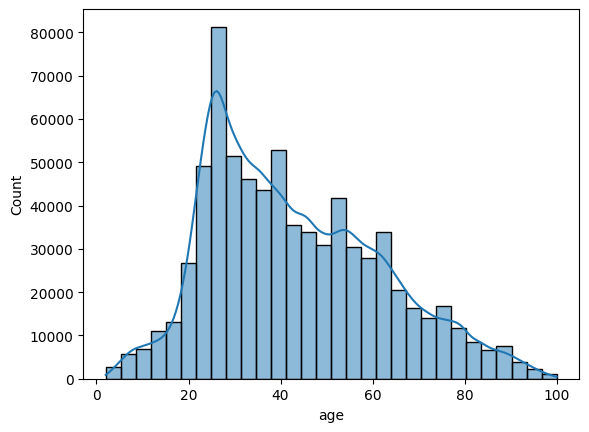

In [226]:
import seaborn as sns
sns.histplot(df_usagers["age"], bins=30, kde=True)

In [227]:
# On va aussi ajouter une colonne accident grave ou non pour faire une classification binaire, ca sera notre target
df_usagers["grav_bin"] = df_usagers["grav"].replace({
    1: 0,  # Non grave
    4: 0,  # Non grave
    2: 1,  # Grave
    3: 1   # Grave
})
# df_usagers.drop(columns="grav", inplace=True)

In [245]:
mapping = {
    0: "Not severly injured",
    1: "Severly injured"
}

counts = df_usagers["grav_bin"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_usagers) * 100:.2f}%")

For Not severly injured proportion: 81.71%
For Severly injured proportion: 18.29%


In [246]:
mapping = {
    1: "Unharmed",
    2: "Killed",
    3: "Hospitalized injury",
    4: "Minor injury"
}

counts = df_usagers["grav"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_usagers) * 100:.2f}%")

For Unharmed proportion: 41.28%
For Minor injury proportion: 40.44%
For Hospitalized injury proportion: 15.58%
For Killed proportion: 2.70%


In [228]:
cols_int = ["place", "catu", "sexe", "age", "aucun", "ceinture", "casque", "dispositif_enfant", "gilet_reflechissant", "airbag", "gants", "gants_airbag", "autre", "grav_bin", "grav"]
df_usagers[cols_int] = df_usagers[cols_int].astype("int64")

In [229]:
df_usagers.columns

Index(['Num_Acc', 'id_vehicule', 'place', 'catu', 'grav', 'sexe', 'aucun',
       'ceinture', 'casque', 'dispositif_enfant', 'gilet_reflechissant',
       'airbag', 'gants', 'gants_airbag', 'autre', 'age', 'grav_bin'],
      dtype='str')

In [230]:
features = ['place', 'catu', 'sexe', 'age',
       'aucun', 'ceinture', 'casque', 'dispositif_enfant',
       'gilet_reflechissant', 'airbag', 'gants', 'gants_airbag', 'autre']

categorical_features = list(set(features) - set(["age"]))
numerical_features = ["age"]
target = 'grav_bin'

In [231]:
df_usagers_analyse = df_usagers.copy()

mapping = {
    1: "Conducteur",
    2: "Passager avant droit",
    3: "Passager arrière droit",
    4: "Passager arrière gauche",
    5: "Passager avant gauche",
    6: "Autre place véhicule léger",
    7: "Transport en commun - place assise",
    8: "Transport en commun - debout",
    9: "Autre transport en commun",
    10: "Piéton (non applicable)"
}

df_usagers_analyse["place"] = df_usagers_analyse["place"].replace(mapping)

mapping = {
    1: "Conducteur",
    2: "Passager",
    3: "Piéton"
}
df_usagers_analyse["catu"] = df_usagers_analyse["catu"].replace(mapping)

mapping = {
    1: "Masculin",
    2: "Féminin"
}
df_usagers_analyse["sexe"] = df_usagers_analyse["sexe"].replace(mapping)

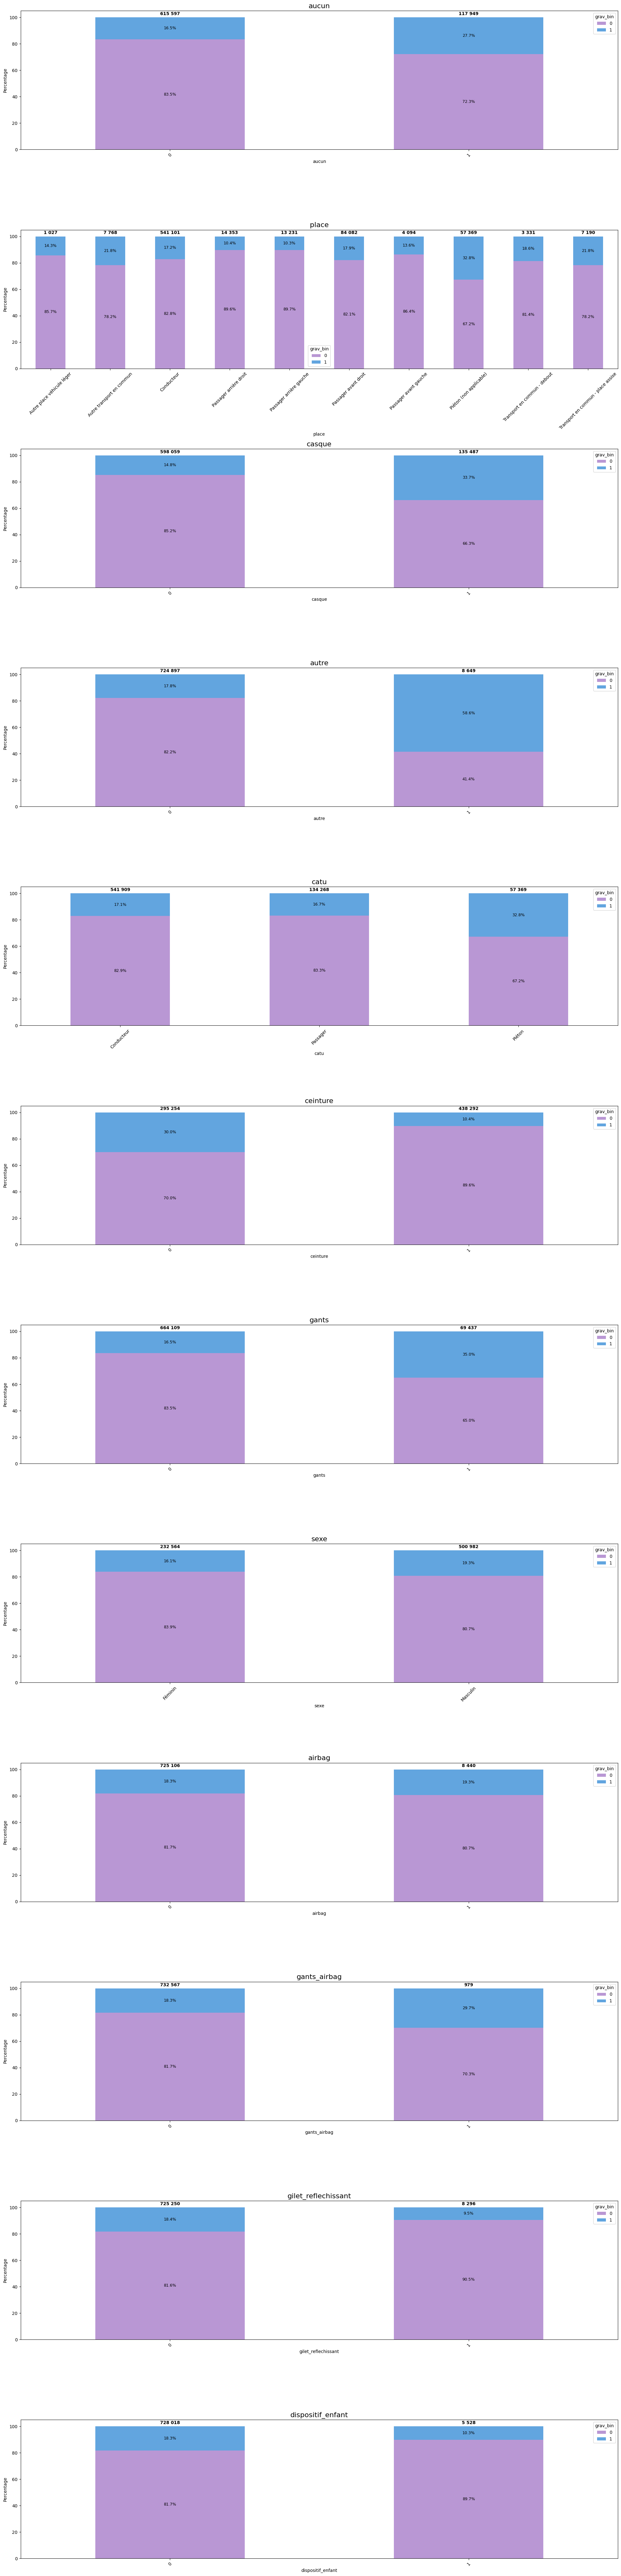

In [232]:
fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

df_usagers_analyse = df_usagers_analyse.reset_index(drop=True)

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_usagers_analyse[feature],
        df_usagers_analyse[target],
        normalize="index"
    ) * 100

    counts = df_usagers_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

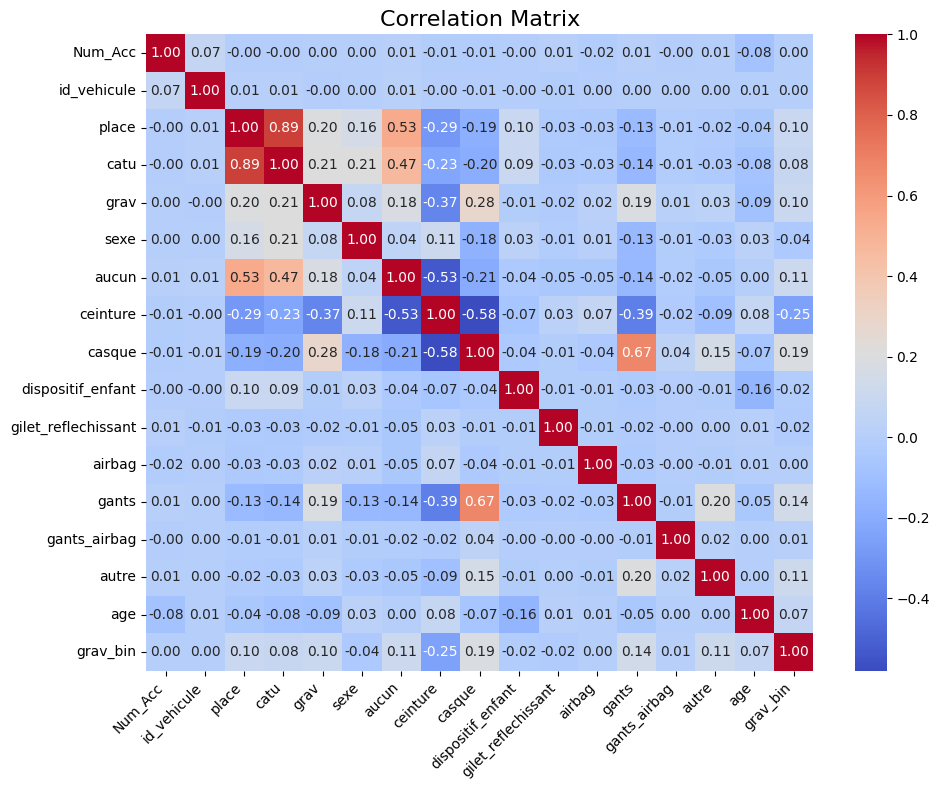

In [257]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_usagers.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [193]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = list(set(features) - set(["age"]))
numerical_features = ['age']

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

X = preprocessor.fit_transform(df_usagers[features])
y = df_usagers[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [194]:
from sklearn.metrics import accuracy_score

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))


 Logistic Regression
Accuracy: 0.8205672983645084

 Decision Tree
Accuracy: 0.817096831491071

 Random Forest
Accuracy: 0.8165298063916708

 Gradient Boosting
Accuracy: 0.821715011818716


AUC of Logistic Regression: 0.721
AUC of Decision Tree: 0.706
AUC of Random Forest: 0.713
AUC of Gradient Boosting: 0.730


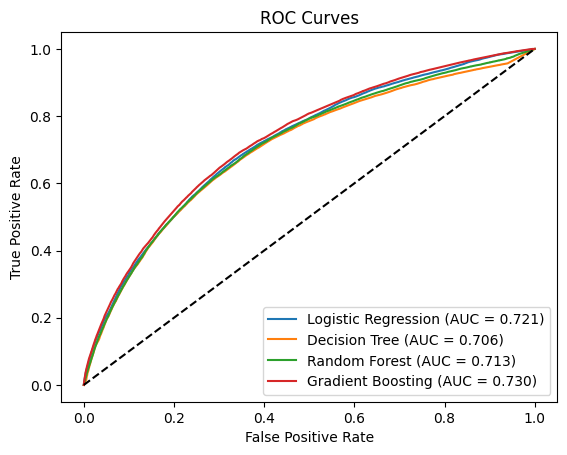

In [195]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

lst_auc = []

for name, model in models.items():

    y_proba = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [234]:
# Finally we are going to save the dataset cleaned
df_usagers.to_csv("df_usagers_clean.csv", index=False)

In [197]:
df_usagers = pandas.read_csv("df_usagers_clean.csv")

In [233]:
df_usagers.info()

<class 'pandas.DataFrame'>
Index: 733546 entries, 0 to 125186
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Num_Acc              733546 non-null  int64
 1   id_vehicule          733546 non-null  int64
 2   place                733546 non-null  int64
 3   catu                 733546 non-null  int64
 4   grav                 733546 non-null  int64
 5   sexe                 733546 non-null  int64
 6   aucun                733546 non-null  int64
 7   ceinture             733546 non-null  int64
 8   casque               733546 non-null  int64
 9   dispositif_enfant    733546 non-null  int64
 10  gilet_reflechissant  733546 non-null  int64
 11  airbag               733546 non-null  int64
 12  gants                733546 non-null  int64
 13  gants_airbag         733546 non-null  int64
 14  autre                733546 non-null  int64
 15  age                  733546 non-null  int64
 16  grav_bin          